# Counterfactual Metrics vs Requested CF Count

This notebook compares the most important counterfactual metrics across result sets where folder names (`1`, `5`, `7`, `10`, ...) represent the number of requested counterfactuals.

It automatically scans numeric subdirectories and builds plots with **requested CF count on the x-axis**.

In [23]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
from explainit.utils.plot_styles import apply_style, COLORS, COLOR_PALETTE

apply_style()
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 100)

In [24]:
RESULTS_DIR = Path('.')  # notebook is expected to live in the results directory

count_dirs = sorted(
    [p for p in RESULTS_DIR.iterdir() if p.is_dir() and re.fullmatch(r'\d+', p.name)],
    key=lambda p: int(p.name)
)

if not count_dirs:
    raise FileNotFoundError('No numeric result directories found (e.g., 1, 5, 7, 10).')

count_dirs

[PosixPath('1'),
 PosixPath('2'),
 PosixPath('3'),
 PosixPath('5'),
 PosixPath('7'),
 PosixPath('10')]

In [25]:
records = []

for d in count_dirs:
    requested_cfs = int(d.name)
    for metrics_file in sorted(d.glob('metrics_*.csv')):
        df = pd.read_csv(metrics_file)
        df['requested_cfs'] = requested_cfs
        df['metrics_file'] = metrics_file.name
        records.append(df)

if not records:
    raise FileNotFoundError('No metrics_*.csv files found inside numeric result directories.')

all_metrics = pd.concat(records, ignore_index=True)
all_metrics = all_metrics.sort_values(['dataset', 'method', 'requested_cfs']).reset_index(drop=True)

print(f'Loaded rows: {len(all_metrics)}')
print(f'Requested CF counts: {sorted(all_metrics["requested_cfs"].unique())}')
print(f'Datasets: {sorted(all_metrics["dataset"].dropna().unique())}')
print(f'Methods: {sorted(all_metrics["method"].dropna().unique())}')

all_metrics.head()

Loaded rows: 90
Requested CF counts: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(10)]
Datasets: ['Communities and Crime', 'Credit Card Default', 'German Credit']
Methods: ['DiCE (official library)', 'Preference (binary)', 'Prototype-Guided', 'Sparse Wachter', 'Wachter']


,dataset,method,n_samples,total_cfs,n_zero_mad_features_excluded,n_cont_features_used_for_mad_metrics,pct_valid_cfs,continuous_proximity,categorical_proximity,continuous_sparsity,continuous_diversity,categorical_diversity,cont_count_diversity,avg_preference_valid_cfs,avg_time_valid_expected,avg_time_all,avg_iterations_valid_expected,avg_iterations_all,requested_cfs,metrics_file
0,Communities and Crime,DiCE (official library),100,100,2,97,0.88,-1.664523,1.0,0.000000,0.000000,0.0,0.000000,50.975450,2.487263,2.336015,182.329545,171.02,1,metrics_communities_and_crime.csv
1,Communities and Crime,DiCE (official library),100,200,2,97,0.88,-1.668758,1.0,0.000052,0.029360,0.0,0.295361,51.002316,3.215777,3.128835,108.693182,105.73,2,metrics_communities_and_crime.csv
2,Communities and Crime,DiCE (official library),100,300,2,97,0.88,-1.671242,1.0,0.000034,0.035815,0.0,0.306048,50.973442,4.398742,4.248438,110.443182,106.60,3,metrics_communities_and_crime.csv
3,Communities and Crime,DiCE (official library),100,500,2,97,0.88,-1.675814,1.0,0.000021,0.051491,0.0,0.339660,50.940162,8.743222,8.551823,116.875000,114.34,5,metrics_communities_and_crime.csv
4,Communities and Crime,DiCE (official library),100,700,2,97,0.88,-1.680118,1.0,0.000059,0.061659,0.0,0.358022,50.898787,12.991077,12.758778,118.670455,116.48,7,metrics_communities_and_crime.csv


## Selected Key Measures

The notebook focuses on these high-level quality and efficiency metrics and uses explicit units on the y-axis:
- `pct_valid_cfs` [%]
- `continuous_proximity` [MAD-scaled, unitless]
- `continuous_sparsity` [fraction]
- `continuous_diversity` [fraction]
- `avg_preference_valid_cfs` [score]
- `avg_time_valid_expected` [seconds]

In [26]:
metrics_to_plot = [
    'pct_valid_cfs',
    'continuous_proximity',
    'continuous_sparsity',
    'continuous_diversity',
    'avg_preference_valid_cfs',
    'avg_time_valid_expected',
]

metric_units = {
    'pct_valid_cfs': '%',
    'continuous_proximity': 'MAD-scaled (unitless)',
    'continuous_sparsity': 'fraction',
    'continuous_diversity': 'fraction',
    'avg_preference_valid_cfs': 'score',
    'avg_time_valid_expected': 'seconds',
}

metric_labels = {m: f"{m} [{metric_units[m]}]" for m in metrics_to_plot}

missing = [m for m in metrics_to_plot if m not in all_metrics.columns]
if missing:
    raise KeyError(f'Missing expected metric columns: {missing}')

datasets = sorted(all_metrics['dataset'].dropna().unique())
x_ticks = sorted(all_metrics['requested_cfs'].unique())

# Create mapping for dataset names to multi-line versions
dataset_name_mapping = {
    'Communities and Crime': 'Communities\nand Crime',
    'Credit Card Default': 'Credit Card\nDefault',
    'German Credit': 'German Credit',  # Keep as is
}

def get_display_name(dataset_name):
    """Map dataset names to display names with line breaks."""
    return dataset_name_mapping.get(dataset_name, dataset_name)

summary_by_dataset_method = (
    all_metrics
.groupby(['requested_cfs', 'dataset', 'method'], as_index=False)[metrics_to_plot]
.mean(numeric_only=True)
)

def plot_metric_with_outlier_inset(
    ax,
    ds_df,
    metric,
    methods,
    method_to_color,
    x_col='requested_cfs',
    ratio_threshold=4.0,
    manual_box=None,
    inset_fontsize=17,
    main_markersize=10.0,  # Increased marker size
    inset_markersize=7.0,  # Increased marker size for inset
):
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    marker_cycle = ['o', 's', '^', 'D', 'P', 'X', 'v', '>', '<', '*', 'h']
    linestyle_cycle = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1))]
    method_styles = {
        m: {
            'marker': marker_cycle[i % len(marker_cycle)],
            'linestyle': linestyle_cycle[i % len(linestyle_cycle)],
        }
        for i, m in enumerate(methods)
    }

    method_frames = {}
    for method in methods:
        mdf = ds_df[ds_df['method'] == method].sort_values(x_col)
        if not mdf.empty and metric in mdf.columns:
            method_frames[method] = mdf

    if not method_frames:
        return None

    all_vals = pd.concat([mdf[metric] for mdf in method_frames.values()]).dropna()
    standout_method = None
    if len(method_frames) >= 2 and not all_vals.empty:
        method_max = {m: mdf[metric].max() for m, mdf in method_frames.items()}
        ordered = sorted(method_max.items(), key=lambda t: t[1], reverse=True)
        top_method, top_max = ordered[0]
        second_max = ordered[1][1]

        non_out_vals = pd.concat(
            [mdf[metric] for m, mdf in method_frames.items() if m != top_method]
).dropna()
        if not non_out_vals.empty:
            span_all = all_vals.max() - all_vals.min()
            span_non = non_out_vals.max() - non_out_vals.min()
            span_non = span_non if span_non > 0 else 1e-12
            if top_max > second_max and (span_all / span_non) >= ratio_threshold:
                standout_method = top_method

    main_methods = [m for m in methods if m in method_frames and m != standout_method]
    if not main_methods:
        main_methods = list(method_frames.keys())

    for method in main_methods:
        mdf = method_frames[method]
        style = method_styles[method]
        ax.plot(
            mdf[x_col],
            mdf[metric],
            marker=style['marker'],
            linestyle=style['linestyle'],
            markersize=main_markersize,  # Larger marker
            markeredgecolor='white',
            markeredgewidth=0.9,
            linewidth=2.2,
            alpha=0.95,
            label=method,
            color=method_to_color[method],
        )

    if standout_method is not None:
        inset_w, inset_h = 0.32, 0.32
        candidate_boxes = [
            ('upper right', (0.66, 0.66, inset_w, inset_h)),
            ('upper left', (0.02, 0.66, inset_w, inset_h)),
            ('lower right', (0.66, 0.02, inset_w, inset_h)),
            ('lower left', (0.02, 0.02, inset_w, inset_h)),
            ('upper right slight out', (0.70, 0.66, inset_w, inset_h)),
            ('lower right slight out', (0.70, 0.02, inset_w, inset_h)),
        ]

        if manual_box is None:
            all_x = pd.concat([mdf[x_col] for mdf in method_frames.values()]).dropna()
            x_min, x_max = all_x.min(), all_x.max()
            y_min, y_max = all_vals.min(), all_vals.max()
            x_span = (x_max - x_min) if x_max != x_min else 1.0
            y_span = (y_max - y_min) if y_max != y_min else 1.0

            points_frac = []
            for mdf in method_frames.values():
                xs = ((mdf[x_col] - x_min) / x_span).tolist()
                ys = ((mdf[metric] - y_min) / y_span).tolist()
                points_frac.extend(zip(xs, ys))

            def coverage_score(box):
                x0, y0, w, h = box
                x1, y1 = x0 + w, y0 + h
                inside_count = sum(
                    1 for x, y in points_frac if x0 <= x <= x1 and y0 <= y <= y1
                )
                outside_penalty = max(0.0, x1 - 1.0) + max(0.0, y1 - 1.0)
                return inside_count + 0.2 * outside_penalty

            _, best_box = min(candidate_boxes, key=lambda item: coverage_score(item[1]))
        else:
            best_box = manual_box

        bx, by, bw, bh = best_box

        inset = inset_axes(
            ax,
            width='100%',
            height='100%',
            loc='lower left',
            bbox_to_anchor=(bx, by, bw, bh),
            bbox_transform=ax.transAxes,
            borderpad=0.0,
        )
        inset.patch.set_alpha(0.25)
        inset.set_facecolor('#f5f5f5')  # Light gray for white background
        for method in methods:
            if method not in method_frames:
                continue
            mdf = method_frames[method]
            style = method_styles[method]
            inset.plot(
                mdf[x_col],
                mdf[metric],
                marker=style['marker'],
                linestyle=style['linestyle'],
                markersize=inset_markersize,  # Larger marker for inset
                markeredgecolor='black',
                markeredgewidth=0.6,
                linewidth=1.2,
                alpha=0.9,
                color=method_to_color[method],
            )
        inset.tick_params(
            axis='both',
            labelsize=inset_fontsize,
            length=4,
            width=1.0,
            colors='black',
        )
        inset.grid(alpha=0.25, color='#cccccc')

    return standout_method

print(f'x_ticks: {x_ticks}')
summary_by_dataset_method.head()


x_ticks: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(10)]


,requested_cfs,dataset,method,pct_valid_cfs,continuous_proximity,continuous_sparsity,continuous_diversity,avg_preference_valid_cfs,avg_time_valid_expected
0,1,Communities and Crime,DiCE (official library),0.88,-1.664523,0.000000,0.0,50.975450,2.487263
1,1,Communities and Crime,Preference (binary),1.00,-1.838653,0.006186,0.0,80.926859,1.969571
2,1,Communities and Crime,Prototype-Guided,1.00,-1.528587,0.002887,0.0,62.261007,1.989902
3,1,Communities and Crime,Sparse Wachter,1.00,-1.139899,0.011546,0.0,60.469869,1.913263
4,1,Communities and Crime,Wachter,1.00,-1.152012,0.010103,0.0,60.601169,1.875716


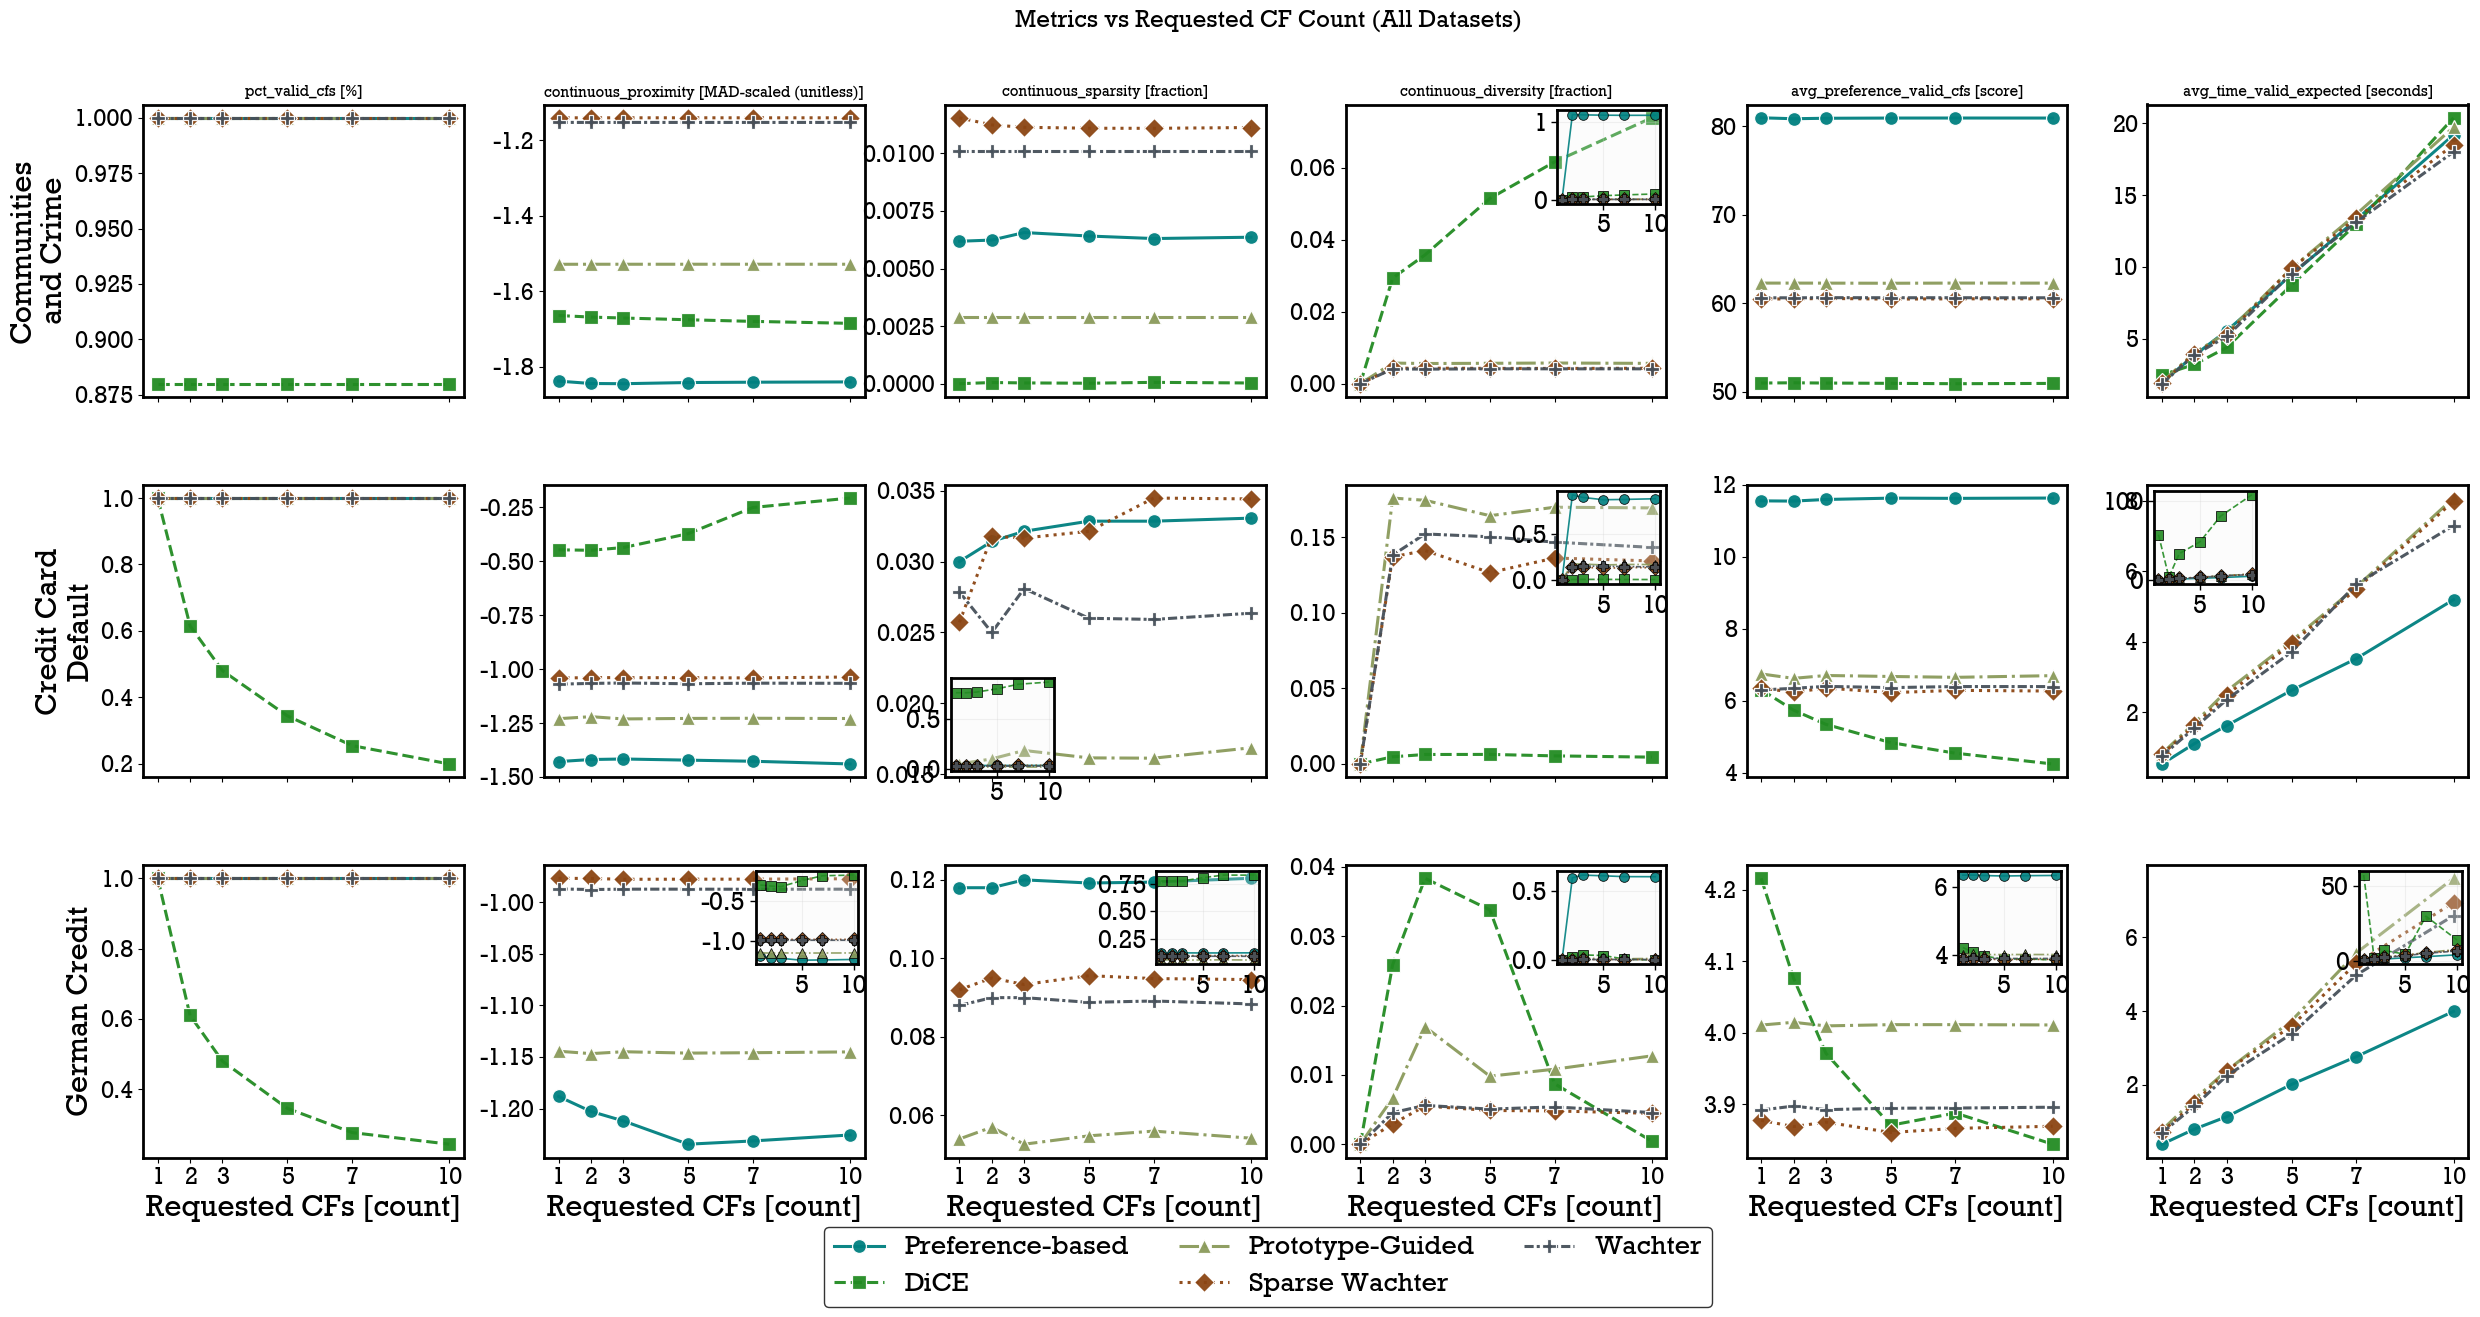

In [27]:
_all_methods = sorted(summary_by_dataset_method['method'].dropna().unique())
_pref  = [m for m in _all_methods if 'preference' in m.lower()]
_dice  = [m for m in _all_methods if 'dice' in m.lower()]
_rest  = [m for m in _all_methods if m not in _pref and m not in _dice]
methods = _pref + _dice + _rest

# Keep canonical method identifiers for computation; map only for display in legends.
method_display_mapping = {
    'DiCE (official library)': 'DiCE',
    'Preference (binary)': 'Preference-based',
}

method_to_color = {m: COLOR_PALETTE[i % len(COLOR_PALETTE)] for i, m in enumerate(methods)}

# Override styling for white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['grid.color'] = '#cccccc'

n_rows = len(datasets)
n_cols = len(metrics_to_plot)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharex=True)

if n_rows == 1 and n_cols == 1:
    axes = [[axes]]
elif n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

for r, ds in enumerate(datasets):
    ds_df = summary_by_dataset_method[summary_by_dataset_method['dataset'] == ds]
    for c, metric in enumerate(metrics_to_plot):
        ax = axes[r][c]
        plot_metric_with_outlier_inset(ax, ds_df, metric, methods, method_to_color, main_markersize=10.0, inset_markersize=7.0)

        if r == 0:
            ax.set_title(metric_labels[metric], fontsize=10)

        if c == 0:
            ax.set_ylabel(get_display_name(ds))

        if r == n_rows - 1:
            ax.set_xlabel('Requested CFs [count]')

axes[0][0].set_xticks(x_ticks)

handles, labels = axes[0][0].get_legend_handles_labels()
display_labels = [method_display_mapping.get(label, label) for label in labels]
fig.legend(
    handles,
    display_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.00),
    ncol=3,
    frameon=True,
    facecolor='white',
    edgecolor='black',
)
fig.suptitle('Metrics vs Requested CF Count (All Datasets)', y=0.97, fontsize=16)
fig.subplots_adjust(top=0.90, bottom=0.12, wspace=0.25, hspace=0.30)
plt.show()


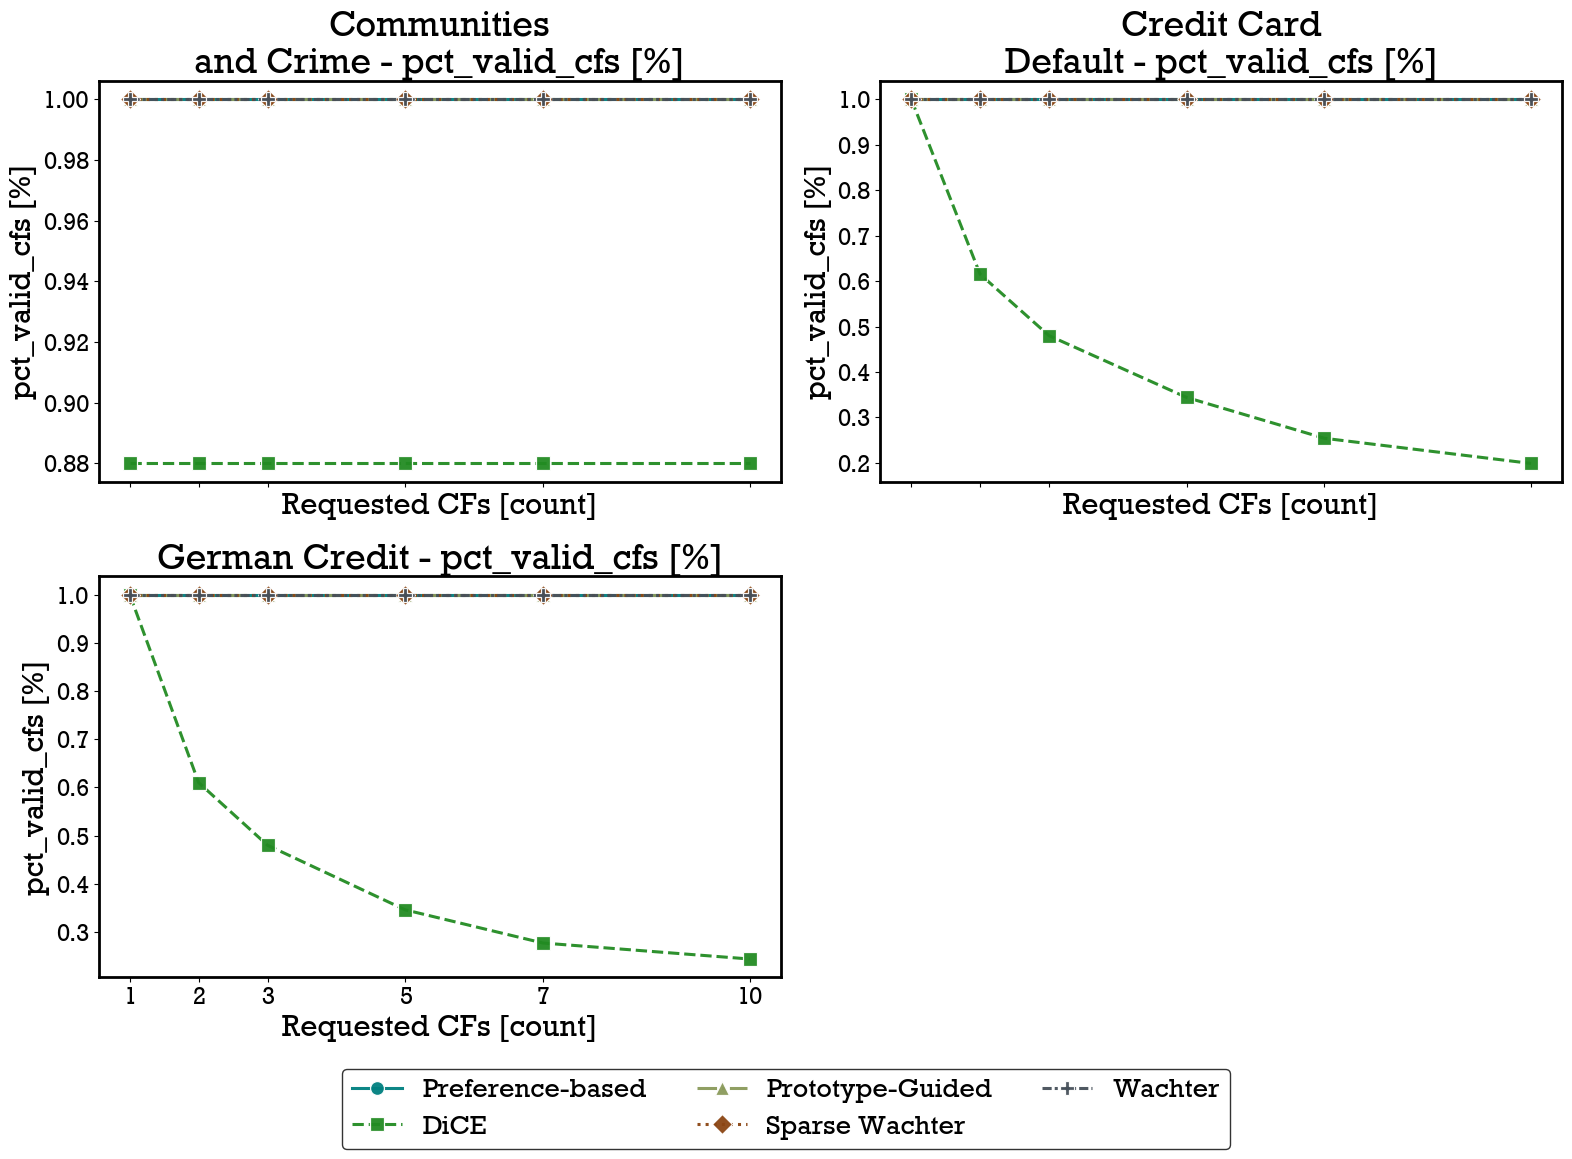

In [28]:
# Per-dataset view for one key metric (validity), to inspect dataset-specific behavior.
key_metric = 'pct_valid_cfs'

# Override styling for white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['grid.color'] = '#cccccc'

n_cols = 2
n_rows = (len(datasets) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows), sharex=True)
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, ds in enumerate(datasets):
    ax = axes[i]
    ds_df = summary_by_dataset_method[summary_by_dataset_method['dataset'] == ds]
    plot_metric_with_outlier_inset(ax, ds_df, key_metric, methods, method_to_color, main_markersize=10.0, inset_markersize=7.0)
    ax.set_title(f"{get_display_name(ds)} - {key_metric} [{metric_units[key_metric]}]")
    ax.set_xlabel('Requested CFs [count]')
    ax.set_ylabel(f"{key_metric} [{metric_units[key_metric]}]")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].set_xticks(x_ticks)

handles, labels = axes[0].get_legend_handles_labels()
display_labels = [method_display_mapping.get(label, label) for label in labels]
fig.legend(
    handles,
    display_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
    facecolor='white',
    edgecolor='black',
)
fig.tight_layout(rect=(0, 0.10, 1, 1))
plt.show()


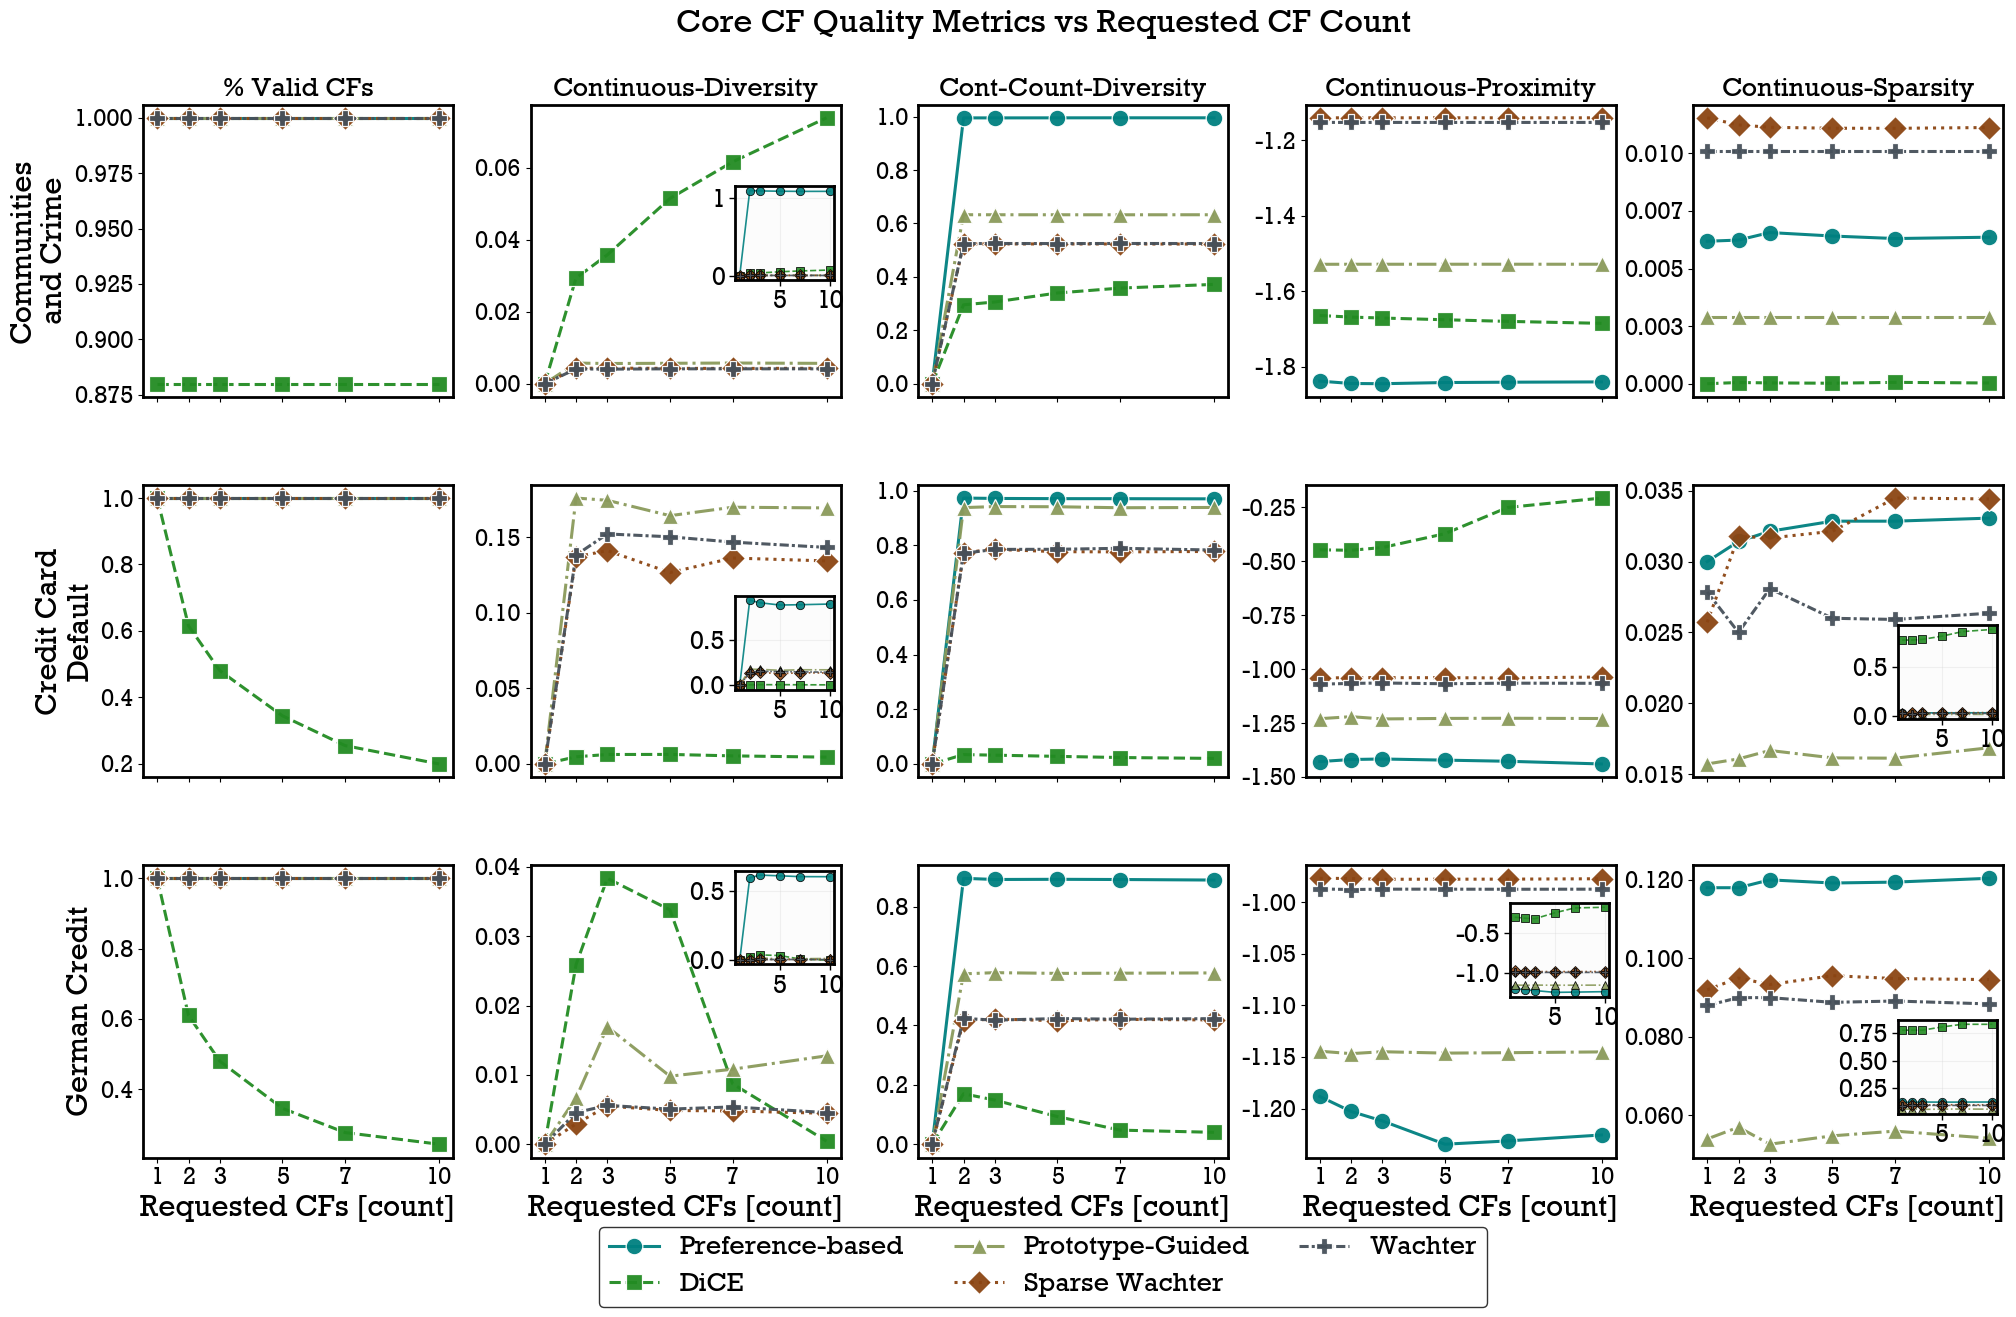

In [29]:
# Core CF-quality metrics view (no units in labels).
quality_metrics = [
    'pct_valid_cfs',
    'continuous_diversity',
    'cont_count_diversity',
    'continuous_proximity',
    'continuous_sparsity',
]

quality_metric_labels = {
    'pct_valid_cfs': '% Valid CFs',
    'continuous_diversity': 'Continuous-Diversity',
    'cont_count_diversity': 'Cont-Count-Diversity',
    'continuous_proximity': 'Continuous-Proximity',
    'continuous_sparsity': 'Continuous-Sparsity',
}

manual_inset_boxes = {
    (0, 'continuous_diversity'): (0.66, 0.40, 0.32, 0.32),   
    (1, 'continuous_diversity'): (0.66, 0.30, 0.32, 0.32),
    (0, 'continuous_sparsity'): (0.66, 0.27, 0.32, 0.32),
    (2, 'continuous_proximity'): (0.66, 0.55, 0.32, 0.32),
    (1, 'continuous_sparsity'): (0.66, 0.20, 0.32, 0.32),
    (2, 'continuous_sparsity'): (0.66, 0.15, 0.32, 0.32),
}

missing_quality = [m for m in quality_metrics if m not in all_metrics.columns]
if missing_quality:
    raise KeyError(f'Missing quality metric columns: {missing_quality}')

quality_summary = (
    all_metrics
.groupby(['requested_cfs', 'dataset', 'method'], as_index=False)[quality_metrics]
.mean(numeric_only=True)
)

# Override styling for white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['grid.color'] = '#cccccc'

n_rows = len(datasets)
n_cols = len(quality_metrics)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.5 * n_rows), sharex=True)

if n_rows == 1 and n_cols == 1:
    axes = [[axes]]
elif n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

for r, ds in enumerate(datasets):
    ds_df = quality_summary[quality_summary['dataset'] == ds]
    for c, metric in enumerate(quality_metrics):
        ax = axes[r][c]
        plot_metric_with_outlier_inset(ax, ds_df, metric, methods, method_to_color, manual_box=manual_inset_boxes.get((r, metric)), main_markersize=12.0, inset_markersize=6.0)

        if metric == 'continuous_sparsity':
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))

        if r == 0:
            ax.set_title(quality_metric_labels[metric], fontsize=18)

        if c == 0:
            ax.set_ylabel(get_display_name(ds))

        if r == n_rows - 1:
            ax.set_xlabel('Requested CFs [count]')

axes[0][0].set_xticks(x_ticks)

handles, labels = axes[0][0].get_legend_handles_labels()
display_labels = [method_display_mapping.get(label, label) for label in labels]
fig.legend(
    handles,
    display_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.00),
    ncol=3,
    frameon=True,
    facecolor='white',
    edgecolor='black',
)
fig.suptitle('Core CF Quality Metrics vs Requested CF Count', y=0.97, fontsize=22)
fig.subplots_adjust(top=0.90, bottom=0.12, wspace=0.25, hspace=0.30)
plt.show()


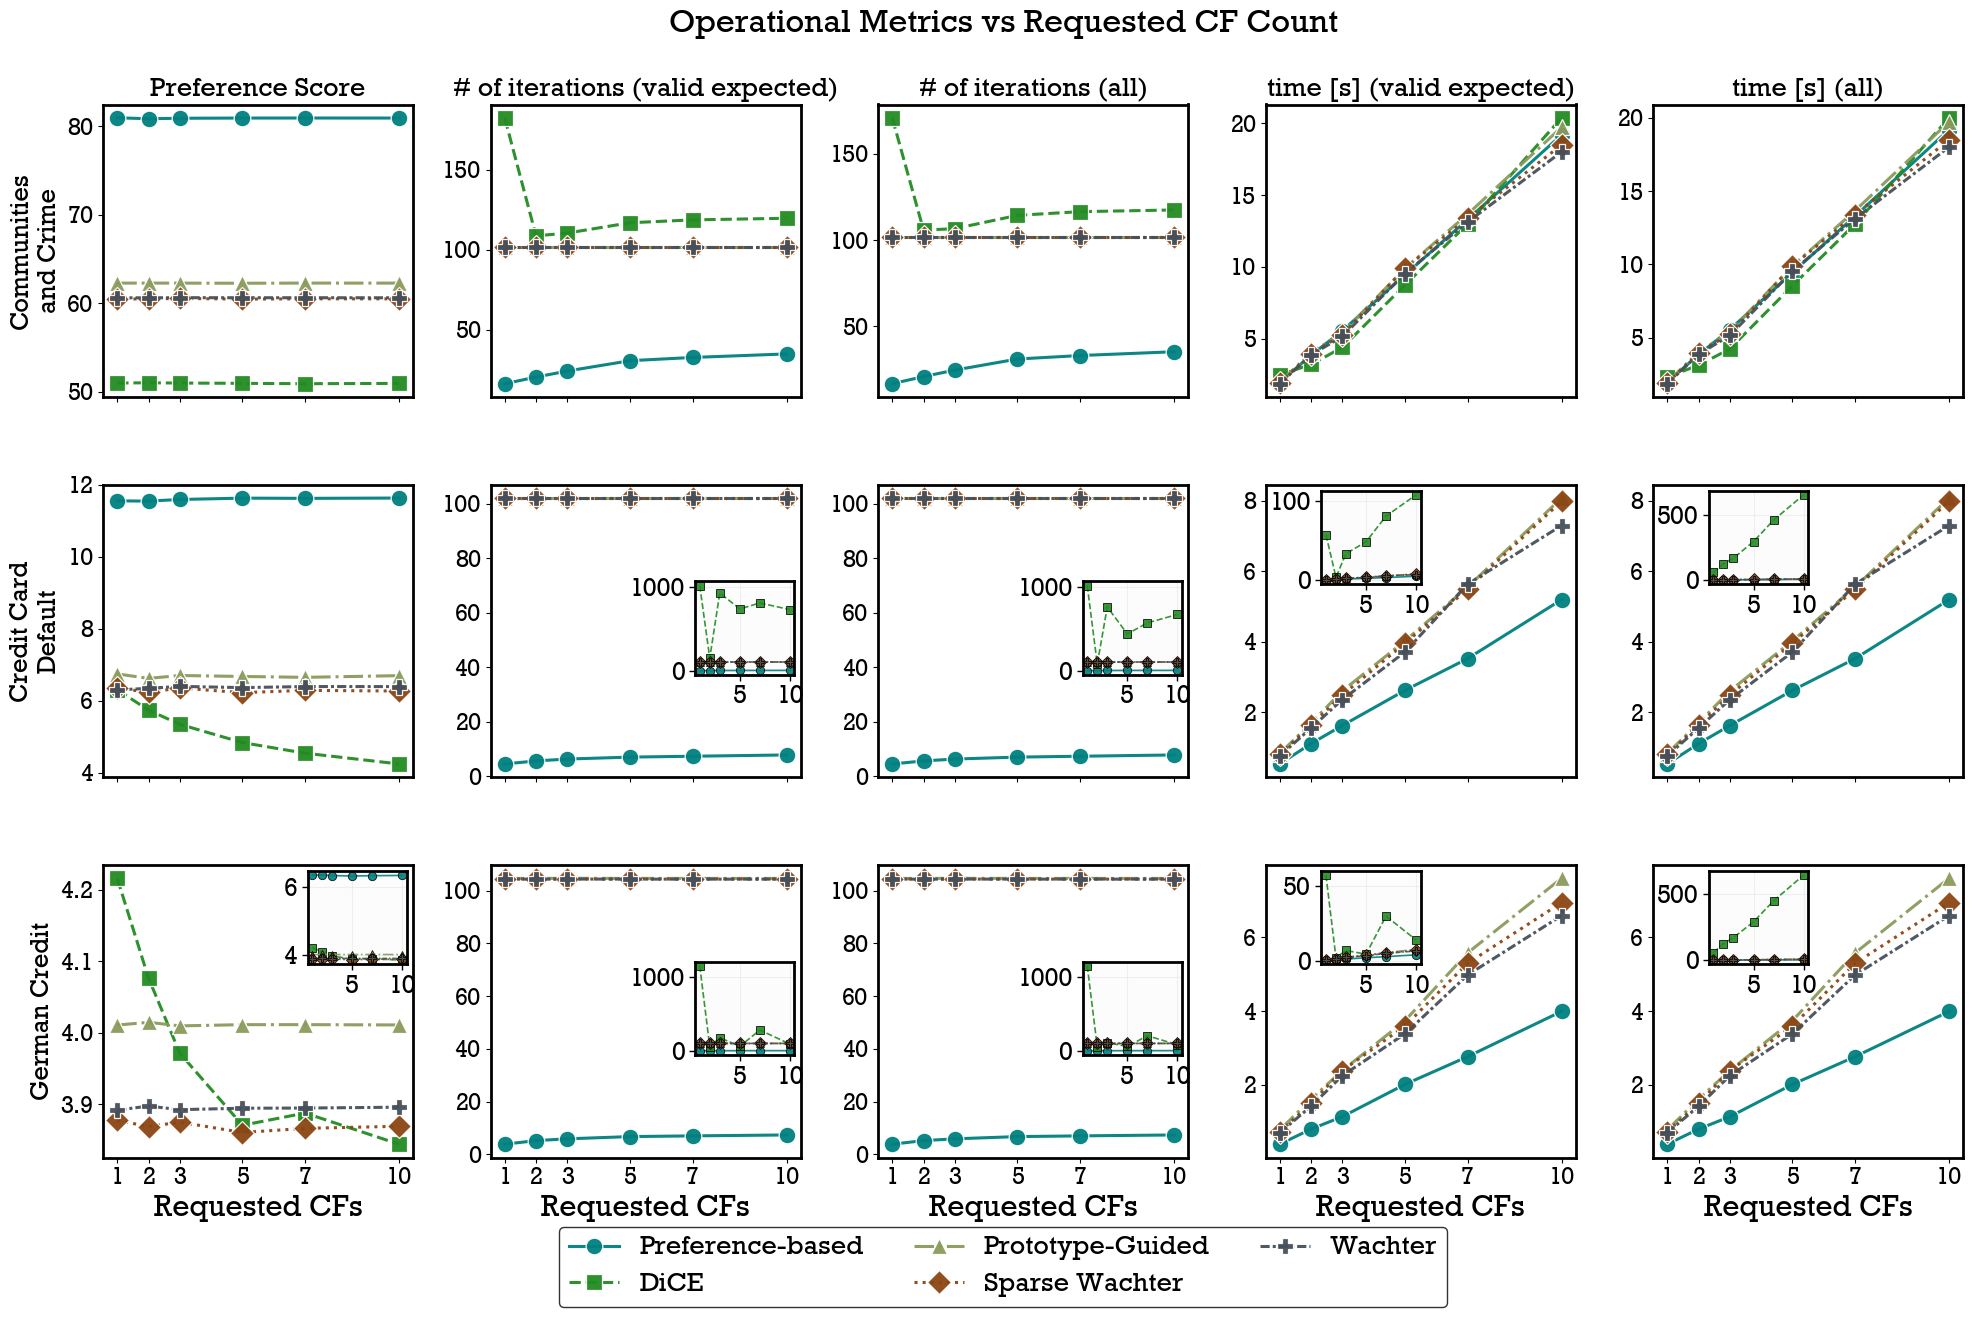

In [30]:
# Business metrics view: preference score, iterations, and time [s]
business_metrics = [
    'avg_preference_valid_cfs',
    'avg_iterations_valid_expected',
    'avg_iterations_all',
    'avg_time_valid_expected',
    'avg_time_all',
]

business_metric_labels = {
    'avg_preference_valid_cfs': 'Preference Score',
    'avg_iterations_valid_expected': '# of iterations (valid expected)',
    'avg_iterations_all': '# of iterations (all)',
    'avg_time_valid_expected': 'time [s] (valid expected)',
    'avg_time_all': 'time [s] (all)',
}

# Manual inset placements requested for specific row/metric combinations.
# row index: 0=first row, 1=second/middle row, 2=third/last row
manual_inset_boxes = {
    (1, 'avg_iterations_valid_expected'): (0.66, 0.35, 0.32, 0.32),  # right bottom
    (2, 'avg_iterations_valid_expected'): (0.66, 0.35, 0.32, 0.32),
    (0, 'avg_iterations_all'): (0.66, 0.35, 0.32, 0.32),             # right upper
    (1, 'avg_iterations_all'): (0.66, 0.35, 0.32, 0.32),             # right bottom
    (2, 'avg_iterations_all'): (0.66, 0.35, 0.32, 0.32),             # right bottom
    (1, 'avg_time_valid_expected'): (0.18, 0.66, 0.32, 0.32),        # right bottom
    (2, 'avg_time_valid_expected'): (0.18, 0.66, 0.32, 0.32),        # upper, leaning left
    (1, 'avg_time_all'): (0.18, 0.66, 0.32, 0.32),                   # upper, leaning left
    (2, 'avg_time_all'): (0.18, 0.66, 0.32, 0.32),                   # upper, leaning left
}

missing_business = [m for m in business_metrics if m not in all_metrics.columns]
if missing_business:
    raise KeyError(f'Missing business metric columns: {missing_business}')

business_summary = (
    all_metrics
.groupby(['requested_cfs', 'dataset', 'method'], as_index=False)[business_metrics]
.mean(numeric_only=True)
)

# Override styling for white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['grid.color'] = '#cccccc'

n_rows = len(datasets)
n_cols = len(business_metrics)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.5 * n_rows), sharex=True)

if n_rows == 1 and n_cols == 1:
    axes = [[axes]]
elif n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

for r, ds in enumerate(datasets):
    ds_df = business_summary[business_summary['dataset'] == ds]
    for c, metric in enumerate(business_metrics):
        ax = axes[r][c]
        manual_box = manual_inset_boxes.get((r, metric))
        plot_metric_with_outlier_inset(
            ax, ds_df, metric, methods, method_to_color, manual_box=manual_box, main_markersize=12.0, inset_markersize=6.0
)

        if r == 0:
            ax.set_title(business_metric_labels[metric], fontsize=18)

        if c == 0:
            ax.set_ylabel(get_display_name(ds), fontsize=17)

        if r == n_rows - 1:
            ax.set_xlabel('Requested CFs')

axes[0][0].set_xticks(x_ticks)

handles, labels = axes[0][0].get_legend_handles_labels()
display_labels = [method_display_mapping.get(label, label) for label in labels]
fig.legend(
    handles,
    display_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.00),
    ncol=3,
    frameon=True,
    facecolor='white',
    edgecolor='black',
)
fig.suptitle('Operational Metrics vs Requested CF Count', y=0.97, fontsize=22)
fig.subplots_adjust(top=0.90, bottom=0.12, wspace=0.25, hspace=0.30)
plt.show()


In [31]:
# Optional: save compact summary tables for reporting.
output_csv_all = RESULTS_DIR / 'requested_cfs_metrics_summary_by_dataset.csv'
summary_by_dataset_method.to_csv(output_csv_all, index=False)

summary_by_method = (
    summary_by_dataset_method
    .groupby(['requested_cfs', 'method'], as_index=False)[metrics_to_plot]
    .mean(numeric_only=True)
)
output_csv_methods = RESULTS_DIR / 'requested_cfs_metrics_summary_by_method.csv'
summary_by_method.to_csv(output_csv_methods, index=False)

output_csv_all, output_csv_methods

(PosixPath('requested_cfs_metrics_summary_by_dataset.csv'),
 PosixPath('requested_cfs_metrics_summary_by_method.csv'))

## Priority Function Inspector

Set `DATASET_KEY`, `SAMPLE_IDX`, and `FEATURE_NAME` in the cell below to build the preference priorities for one sample.  
The following cell then plots the theoretical priority function and the empirical sampling distribution for the chosen feature.

In [32]:
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── User-configurable parameters ──────────────────────────────────────────────
DATASET_KEY   = 'german_credit'   # 'german_credit' | 'communities_and_crime' | 'credit_card_default'
SAMPLE_IDX    = 0                       # index into X_test
FEATURE_NAME  = 'credit_amount'             # feature name (or set to None to use FEATURE_IDX)
FEATURE_IDX   = 9                       # used only when FEATURE_NAME is None
TARGET_CLASS  = 1
TARGET_PROB   = 0.85
EXEMPLAR_W    = 0.75
STEEPNESS     = 2
# ──────────────────────────────────────────────────────────────────────────────

MARCH_DIR = Path('.').resolve().parent   # results/ → march-article/
DATA_DIR  = MARCH_DIR / 'data'
sys.path.insert(0, str(MARCH_DIR))

import test_all as _test_all_mod
from test_all import define_preferences, DATASET_NAMES, load_dataset
import tensorflow as tf
from explainit.explainers.random_search import RandomSearchExplainer

# Inject a minimal config stub so find_target_sample doesn't crash
# (it references the module-level `config` only for a debug log line)
_test_all_mod.config = {'output': {'verbose': False}}
find_target_sample = _test_all_mod.find_target_sample

# Load cached dataset
_data = load_dataset(DATASET_KEY)
pref_X_train      = _data['X_train']
pref_X_test       = _data['X_test']
pref_y_train      = _data['y_train']
pref_feature_names = list(_data['feature_names'])

# Load model
_clean = DATASET_NAMES[DATASET_KEY].lower().replace(' ', '_').replace('&', 'and')
pref_model = tf.keras.models.load_model(MARCH_DIR / 'models' / f'{_clean}_model.keras')

# Extract chosen sample
_X_test_np = pref_X_test.values if hasattr(pref_X_test, 'values') else pref_X_test
pref_sample = _X_test_np[SAMPLE_IDX]
_pred = float(pref_model.predict(pref_sample.reshape(1, -1), verbose=0)[0, 0])
print(f"Dataset      : {DATASET_NAMES[DATASET_KEY]}")
print(f"Sample index : {SAMPLE_IDX}  —  model prediction = {_pred:.4f}")

# Find target exemplar
pref_target_sample = find_target_sample(
    pref_X_train, pref_y_train, pref_model,
    target_class=TARGET_CLASS,
    target_probability=TARGET_PROB,
)
_tpred = float(pref_model.predict(pref_target_sample.reshape(1, -1), verbose=0)[0, 0])
print(f"Target exemplar prediction = {_tpred:.4f}")

# Build priorities
pref_preferences, pref_params = define_preferences(
    sample=pref_sample,
    target_sample=pref_target_sample,
    X_train=pref_X_train,
    feature_names=pref_feature_names,
    exemplar_weight=EXEMPLAR_W,
    steepness=STEEPNESS,
)

# Build RandomSearchExplainer (needed to access sample_numeric_value)
_model_pred = lambda x: pref_model.predict(np.array(x), verbose=0).flatten()
pref_explainer = RandomSearchExplainer(
    model_pred=_model_pred,
    priorities=pref_preferences,
    sample=pref_sample.tolist(),
    target=TARGET_PROB,
)

# Resolve feature index
pref_feat_idx = (
    pref_feature_names.index(FEATURE_NAME)
    if FEATURE_NAME is not None
    else FEATURE_IDX
)
pref_feat_name = pref_feature_names[pref_feat_idx]
print(f"\nPriorities ready for {len(pref_preferences['numerical'])} features.")
print(f"Selected feature: [{pref_feat_idx}] {pref_feat_name}")
p = pref_params[pref_feat_idx]
print(f"  sample_value        = {p['sample_value']:.4f}")
print(f"  target_value        = {p['target_value']:.4f}")
print(f"  midpoint            = {p['midpoint']:.4f}")
print(f"  direction           = {p['direction']}  (increasing={p['increasing']})")
print(f"  x0                  = {p['x0']:.4f}")
print(f"  x1                  = {p['x1']:.4f}")
print(f"  acceptable_min/max  = [{p['acceptable_min']:.4f}, {p['acceptable_max']:.4f}]")
print(f"  dataset_min/max     = [{p['dataset_min']:.4f}, {p['dataset_max']:.4f}]")
print(f"  feature_coverage    = {p['feature_coverage_pct']:.1f}%")


2026-04-12 12:27:29,033 - INFO - test_all - ✓ Dataset loaded from: /Users/bartosz/projects/explainit/explainit_project/explainit/experiments/march-article/data/german_credit_data.pkl
2026-04-12 12:27:29,033 - INFO - test_all -   Saved on: 2026-03-08T18:05:14.748176
2026-04-12 12:27:29,034 - INFO - test_all -   Train shape: (800, 7), Test shape: (200, 7)


Dataset      : German Credit
Sample index : 0  —  model prediction = 0.8961
Target exemplar prediction = 0.8505

Priorities ready for 7 features.
Selected feature: [1] credit_amount
  sample_value        = -0.2740
  target_value        = 1.2253
  midpoint            = 0.4756
  direction           = decreasing  (increasing=False)
  x0                  = 0.4756
  x1                  = 2.0465
  acceptable_min/max  = [-0.2740, 5.5026]
  dataset_min/max     = [-1.0602, 5.5026]
  feature_coverage    = 45.9%


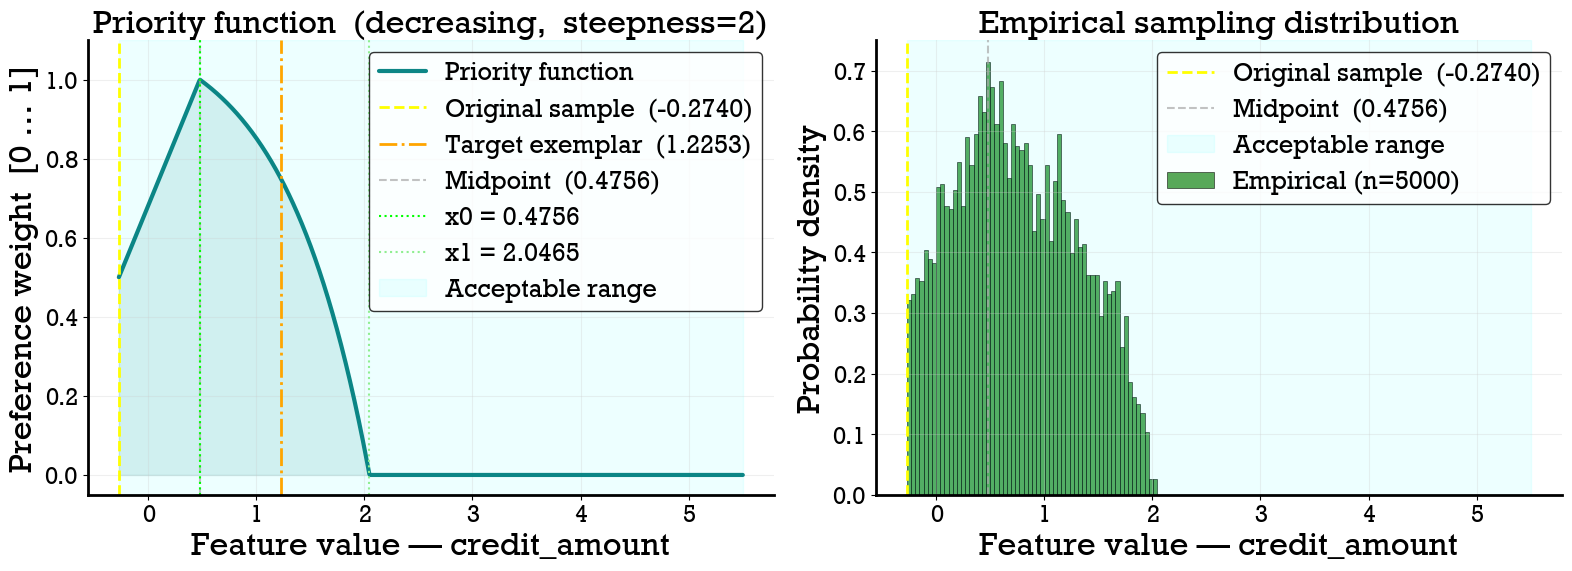

In [33]:
# ── User-configurable ────────────────────────────────────────────────────────
N_EMPIRICAL = 5000   # number of rejection-sampled values for empirical histogram
# ─────────────────────────────────────────────────────────────────────────────
from explainit.utils.plot_styles import apply_style, COLORS, get_line_color, style_numerical_plot
apply_style()

# Override styling for white background AFTER apply_style()
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['grid.color'] = '#cccccc'

constraint = pref_explainer.filtered_priorities['numerical'].get(pref_feat_idx)

if not isinstance(constraint, dict) or 'function' not in constraint:
    print(f"Feature '{pref_feat_name}' is unactionable (fixed at {constraint}).")
else:
    min_val = constraint['min']
    max_val = constraint['max']
    f       = constraint['function']

    # ── Raw priority function (0..1), as defined by the exponential ───────
    x_vals  = np.linspace(min_val, max_val, 1000)
    weights = np.array([float(f(x)) for x in x_vals])   # NOT normalized

    # ── Empirical distribution (uses RandomSearchExplainer.sample_numeric_value) ──
    accepted = [pref_explainer.sample_numeric_value(constraint) for _ in range(N_EMPIRICAL)]

    # ── Plot: two subplots ────────────────────────────────────────────────
    fig, (ax_prio, ax_emp) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

    # ── Left: raw priority function ───────────────────────────────────────
    p = pref_params[pref_feat_idx]
    ax_prio.set_facecolor('white')
    ax_prio.plot(x_vals, weights,
                 label='Priority function',
                 color=get_line_color('theoretical'),
                 linewidth=3, alpha=0.95, solid_capstyle='round')
    ax_prio.fill_between(x_vals, weights, alpha=0.12,
                         color=get_line_color('theoretical'))

    ax_prio.axvline(pref_sample[pref_feat_idx],
                    color='yellow', linestyle='--', linewidth=2.0,
                    label=f"Original sample  ({p['sample_value']:.4f})")
    ax_prio.axvline(p['target_value'],
                    color='orange', linestyle='-.', linewidth=2.0,
                    label=f"Target exemplar  ({p['target_value']:.4f})")
    ax_prio.axvline(p['midpoint'],
                    color='darkgray', linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f"Midpoint  ({p['midpoint']:.4f})")
    ax_prio.axvline(p['x0'],
                    color='lime', linestyle=':', linewidth=1.5,
                    label=f"x0 = {p['x0']:.4f}")
    ax_prio.axvline(p['x1'],
                    color='lightgreen', linestyle=':', linewidth=1.5,
                    label=f"x1 = {p['x1']:.4f}")
    ax_prio.axvspan(p['acceptable_min'], p['acceptable_max'],
                    alpha=0.07, color='cyan',
                    label=f"Acceptable range")

    ax_prio.set_ylim(-0.05, 1.10)
    ax_prio.set_xlabel(f'Feature value — {pref_feat_name}', fontsize=22)
    ax_prio.set_ylabel('Preference weight  [0 … 1]', fontsize=22)
    ax_prio.set_title(
        f'Priority function  ({p["direction"]},  steepness={STEEPNESS})', fontsize=22)
    ax_prio.tick_params(colors='black')
    ax_prio.spines['left'].set_color('black')
    ax_prio.spines['bottom'].set_color('black')
    ax_prio.spines['top'].set_visible(False)
    ax_prio.spines['right'].set_visible(False)
    ax_prio.grid(alpha=0.3, color='#cccccc')
    lg = ax_prio.legend(facecolor='white',
                        edgecolor='black', fontsize=17)
    for t in lg.get_texts():
        t.set_color('black')

    # ── Right: empirical sampling distribution ────────────────────────────
    ax_emp.set_facecolor('white')
    hist, bin_edges = np.histogram(accepted, bins=60, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax_emp.bar(bin_centers, hist, width=np.diff(bin_edges),
               alpha=0.75, label=f'Empirical (n={N_EMPIRICAL})',
               color=get_line_color('empirical'),
               edgecolor='black', linewidth=0.5)

    ax_emp.axvline(pref_sample[pref_feat_idx],
                   color='yellow', linestyle='--', linewidth=2.0,
                   label=f"Original sample  ({p['sample_value']:.4f})")
    ax_emp.axvline(p['midpoint'],
                   color='darkgray', linestyle='--', linewidth=1.5, alpha=0.7,
                   label=f"Midpoint  ({p['midpoint']:.4f})")
    ax_emp.axvspan(p['acceptable_min'], p['acceptable_max'],
                   alpha=0.07, color='cyan',
                   label=f"Acceptable range")

    ax_emp.set_xlabel(f'Feature value — {pref_feat_name}', fontsize=22)
    ax_emp.set_ylabel('Probability density', fontsize=22)
    ax_emp.set_title(f'Empirical sampling distribution', fontsize=22)
    ax_emp.tick_params(colors='black')
    ax_emp.spines['left'].set_color('black')
    ax_emp.spines['bottom'].set_color('black')
    ax_emp.spines['top'].set_visible(False)
    ax_emp.spines['right'].set_visible(False)
    ax_emp.grid(alpha=0.3, color='#cccccc')
    lg2 = ax_emp.legend(facecolor='white',
                         edgecolor='black', fontsize=17)
    for t in lg2.get_texts():
        t.set_color('black')

    # fig.suptitle(
    #     f'{pref_feat_name}  |  {DATASET_NAMES[DATASET_KEY]}  |  sample idx {SAMPLE_IDX}',
    #     fontsize=14, y=1.01, color='black',
    # )
    plt.tight_layout()
    plt.show()
